Phase 1: Data Audit & Understanding
Empty On The Map

Objective

The purpose of this notebook is to inspect the raw datasets, understand their structure, and identify data quality issues before building business metrics such as Demand Signal, Distribution Gap, Competitive Intensity, and the Whitespace Confidence Index.

Import Libraries

In [2]:
import pandas as pd
import numpy as np
import json
import os

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 10)

Define Paths

In [3]:
# Project paths

PROJECT_ROOT = Path("..")
RAW_DATA = PROJECT_ROOT / "data" / "raw"

print(RAW_DATA)

..\data\raw


Load CSV Files

In [18]:
retail_panel = pd.read_csv(RAW_DATA/"retail_panel.csv")
competitor = pd.read_csv(RAW_DATA/"competitor_activity.csv")
kestrel = pd.read_csv(RAW_DATA/"kestrel_sales.csv")

Load JSON

In [22]:
audience = pd.read_json(
RAW_DATA/"audience_signal.jsonl",lines=True
)

Load Excel Workbook

This workbook intentionally contains a sheet where headers are not on the first row.

First inspect the sheet names.

In [23]:
excel = pd.ExcelFile(RAW_DATA/"market_master.xlsx")

excel.sheet_names

['District_Master', 'Panel_Coverage', 'Distribution_Audit']

In [24]:
district_master = pd.read_excel(
    RAW_DATA/"market_master.xlsx",
    sheet_name="District_Master",
    header=4
)

panel_coverage = pd.read_excel(
    RAW_DATA/"market_master.xlsx",
    sheet_name="Panel_Coverage"
)

distribution = pd.read_excel(
    RAW_DATA/"market_master.xlsx",
    sheet_name="Distribution_Audit"
)

Dataset Overview

Shapes

In [25]:
datasets = {
    "Retail Panel": retail_panel,
    "Competitor Activity": competitor,
    "Kestrel Sales": kestrel,
    "Audience Signal": audience,
    "District Master": district_master,
    "Panel Coverage": panel_coverage,
    "Distribution": distribution
}

summary = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

summary

,Dataset,Rows,Columns
0,Retail Panel,1428039,21
1,Competitor Activity,41616,12
2,Kestrel Sales,49939,13
3,Audience Signal,393815,19
4,District Master,340,9
5,Panel Coverage,8160,8
6,Distribution,8160,9


Inspect Columns

In [26]:
for name, df in datasets.items():
    print("="*70)
    print(name)
    print(df.columns.tolist())
    print()

Retail Panel
['audit_timestamp', 'month_id', 'outlet_id', 'numeric_outlet_id', 'district_id', 'district_name', 'state', 'country', 'channel', 'pos_system', 'brand', 'sku_id', 'sku_name', 'pack_size_ml', 'units_sold', 'unit_price_inr', 'mrp_inr', 'discount_pct', 'projection_weight', 'store_audit_notes', 'is_late_submission']

Competitor Activity
['audit_date', 'month_id', 'district_id', 'district_name', 'state', 'competitor_brand', 'numeric_distribution_pct', 'weighted_distribution_pct', 'stocking_outlet_count', 'exclusive_branded_chillers_deployed', 'promotional_intensity_score_1_to_10', 'active_retail_scheme']

Kestrel Sales
['dispatch_date', 'month_id', 'district_id', 'district_name', 'state', 'sku_id', 'sku_name', 'factory_dispatch_units', 'distributor_sellout_units', 'reported_stocking_outlets', 'net_billing_revenue_inr', 'distributor_code', 'data_source']

Audience Signal
['event_id', 'month_id', 'event_timestamp', 'ingestion_timestamp', 'days_to_ingest', 'district_id', 'district_

First Look

In [27]:
for name, df in datasets.items():
    print("="*70)
    print(name)
    display(df.head(3))

Retail Panel


,audit_timestamp,month_id,outlet_id,numeric_outlet_id,district_id,district_name,state,country,channel,pos_system,brand,sku_id,sku_name,pack_size_ml,units_sold,unit_price_inr,mrp_inr,discount_pct,projection_weight,store_audit_notes,is_late_submission
0,08-08-2025,2025-08,OUT-003356,3356,DST_0184,Kolkata,West Bengal,ind,General Trade / Kirana,Manual_Logbook,PulseDrop,PLS_COFFEE_250,PulseDrop Espresso 250ml,250,24,NaN,175.0,0.0,581.88,NaN,False
1,2026-06-06T00:00:00Z,2026-06,3173,3173,DST_0165,Mehsana,Gujarat,IND,GT_Kirana,PineLabs_POS_Cloud,Torque,TRQ_RED_250,Torque Nitro Red 250ml,250,4,75.0,75.0,0.0,1.00,NaN,False
2,18-06-2025,2025-06,OUT-002862,2862,DST_0142,Barabanki,Uttar Pradesh,INDIA,General Trade / Kirana,PineLabs_POS_Cloud,BullForce,BLF_ORIG_250,BullForce Regular 250ml,250,7,60.0,60.0,NaN,180.29,NaN,False


Competitor Activity


,audit_date,month_id,district_id,district_name,state,competitor_brand,numeric_distribution_pct,weighted_distribution_pct,stocking_outlet_count,exclusive_branded_chillers_deployed,promotional_intensity_score_1_to_10,active_retail_scheme
0,2026-07-15T00:00:00+05:30,2026-07,DST_0043,Shivamogga,Karnataka,Torque,47.71,54.00,1090,104,4.69,NaN
1,2025/03/15,2025-03,DST_0292,Sri Sathya Sai,Andhra Pradesh,BullForce,38.60,58.47,786,78,4.31,NaN
2,2025-09-09T00:00:00+05:30,2025-09,DST_0024,Dhule,Maharashtra,Torque,45.81,49.59,1119,77,4.01,Seasonal_Discount


Kestrel Sales


...

,District_Code,District_Name,State_Union_Territory,Total_Population,Urban_Population_Share_Pct,Rural_Population_Share_Pct,Median_Income_Band,Estimated_Total_Retail_Universe,Census_Demographic_Notes
0,DST_0001,Mumbai Suburban,Maharashtra,9356962,100,0,High,18500,NaN
1,DST_0002,Mumbai City,Maharashtra,3085411,100,0,High,6787,NaN
2,DST_0003,Pune,Maharashtra,9429408,61,39,High,15596,NaN


Panel Coverage


,District_Ref_ID,Month,District_Name,State,Sampled_Outlets,Estimated_Total_Outlets,Panel_Coverage_Pct,Audit_Reliability_Tier
0,DST-0001,2024-09,Mumbai Suburban,Maharashtra,17,18500,86.62,High
1,DST-0002,2024-09,Mumbai City,Maharashtra,17,6787,80.00,High
2,3,2024-09,Pune,Maharashtra,17,15596,84.79,High


Distribution


,Audit_Cycle,District_ID,District_Name,State,Outlets_Stocking_Kestrel,Outlets_Stocking_Category,Estimated_Total_Universe,Apparent_Kestrel_Numeric_Dist_Pct,Apparent_Category_Numeric_Dist_Pct
0,2024-09,DST_0001,Mumbai Suburban,Maharashtra,9976,15117,18500,53.92,81.71
1,2024-09,DST_0002,Mumbai City,Maharashtra,3629,5346,6787,53.47,78.77
2,2024-09,DST_0003,Pune,Maharashtra,7037,12407,15596,45.12,79.55


Data Types

In [28]:
dtype_summary = {}

for name, df in datasets.items():
    dtype_summary[name] = df.dtypes.value_counts()

dtype_summary

{'Retail Panel': object     13
 float64     4
 int64       3
 bool        1
 Name: count, dtype: int64,
 'Competitor Activity': object     7
 float64    3
 int64      2
 Name: count, dtype: int64,
 'Kestrel Sales': object     9
 int64      3
 float64    1
 Name: count, dtype: int64,
 'Audience Signal': object     15
 int64       2
 float64     2
 Name: count, dtype: int64,
 'District Master': object    5
 int64     4
 Name: count, dtype: int64,
 'Panel Coverage': object     5
 int64      2
 float64    1
 Name: count, dtype: int64,
 'Distribution': object     4
 int64      3
 float64    2
 Name: count, dtype: int64}

Missing Values

In [29]:
for name, df in datasets.items():

    missing = (
        df.isna()
        .mean()
        .mul(100)
        .sort_values(ascending=False)
    )

    print("="*70)
    print(name)
    display(missing[missing>0].round(2))

Retail Panel


store_audit_notes    91.57
unit_price_inr       11.52
discount_pct          7.50
projection_weight     2.01
dtype: float64

Competitor Activity


active_retail_scheme    67.14
dtype: float64

Kestrel Sales


...

Census_Demographic_Notes    97.94
dtype: float64

Panel Coverage


Series([], dtype: float64)

Distribution


Series([], dtype: float64)

Duplicate Check

In [30]:
for name, df in datasets.items():

    dup = df.duplicated().sum()

    print(f"{name}: {dup:,} exact duplicates")

Retail Panel: 27,746 exact duplicates
Competitor Activity: 816 exact duplicates
Kestrel Sales: 979 exact duplicates
Audience Signal: 7,645 exact duplicates
District Master: 0 exact duplicates
Panel Coverage: 0 exact duplicates
Distribution: 0 exact duplicates


Date Inspection

In [31]:
for name, df in datasets.items():

    date_cols = [
        c for c in df.columns
        if "date" in c.lower()
        or "time" in c.lower()
        or "month" in c.lower()
    ]

    if date_cols:
        print("="*70)
        print(name)

        for c in date_cols:
            print(c)
            display(df[c].head())

Retail Panel
audit_timestamp


0              08-08-2025
1    2026-06-06T00:00:00Z
2              18-06-2025
3                03-16-25
4              23-01-2025
Name: audit_timestamp, dtype: object

month_id


0    2025-08
1    2026-06
2    2025-06
3    2025-03
4    2025-01
Name: month_id, dtype: object

Competitor Activity
audit_date


...

0       2025/08/28 22:07:24
1       2026/02/08 01:42:53
2       27-06-2025 16:52:38
3    1738990080000 14:19:04
4       2026/04/16 06:50:01
Name: event_timestamp, dtype: object

ingestion_timestamp


0      08-28-25
1    08-02-2026
2      06-27-25
3    08-02-2025
4    2026/04/16
Name: ingestion_timestamp, dtype: object

Panel Coverage
Month


0    2024-09
1    2024-09
2    2024-09
3    2024-09
4    2024-09
Name: Month, dtype: object

Panel Coverage Inspection

In [32]:
panel_coverage.describe(include="all")

,District_Ref_ID,Month,District_Name,State,Sampled_Outlets,Estimated_Total_Outlets,Panel_Coverage_Pct,Audit_Reliability_Tier
count,8160,8160,8160,8160,8160.000000,8160.000000,8160.000000,8160
unique,680,24,382,12,NaN,NaN,NaN,4
top,312,2024-09,Wayanad,Uttar Pradesh,NaN,NaN,NaN,Standard
freq,20,340,24,960,NaN,NaN,NaN,5157
mean,NaN,NaN,NaN,NaN,11.938971,3115.829412,47.231262,NaN
...,...,...,...,...,...,...,...,...
min,NaN,NaN,NaN,NaN,1.000000,217.000000,10.000000,NaN
25%,NaN,NaN,NaN,NaN,8.000000,1478.000000,38.147500,NaN
50%,NaN,NaN,NaN,NaN,14.000000,2389.000000,47.875000,NaN
75%,NaN,NaN,NaN,NaN,17.000000,3781.250000,59.020000,NaN


Using coverage column: Panel_Coverage_Pct


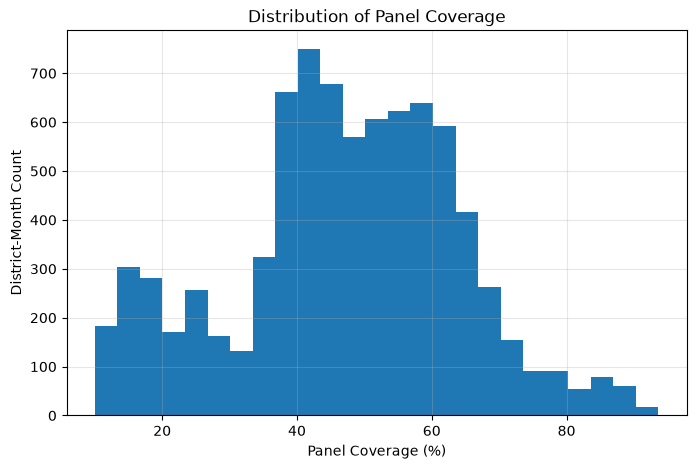

In [33]:
import matplotlib.pyplot as plt

# Find the column containing "coverage"
coverage_col = None
for col in panel_coverage.columns:
    if "coverage" in str(col).lower():
        coverage_col = col
        break

if coverage_col is None:
    raise ValueError(f"No coverage column found. Available columns: {panel_coverage.columns.tolist()}")

print(f"Using coverage column: {coverage_col}")

plt.figure(figsize=(8,5))
plt.hist(panel_coverage[coverage_col].dropna(), bins=25)
plt.xlabel("Panel Coverage (%)")
plt.ylabel("District-Month Count")
plt.title("Distribution of Panel Coverage")
plt.grid(alpha=0.3)
plt.show()

This immediately tells us whether:

metros cluster high

rural districts cluster low

Business Audit Summary

 # Purpose

This audit was completed before any preprocessing or business modeling to ensure that subsequent analysis is based on a clear understanding of the available data and its limitations.

# Key Findings

- Successfully loaded the available datasets and verified their overall structure.
- Confirmed that the Excel workbook contains multiple sheets and requires non-standard header handling for at least one sheet.
- Identified data quality characteristics such as missing values, duplicate records, mixed data types, and inconsistent field formats that will be addressed during preprocessing.
- Verified that temporal information spans the expected historical period and contains multiple timestamp formats that require careful parsing.
- Examined panel coverage across districts, highlighting that coverage varies significantly and must be considered before making market expansion recommendations.
- Preserved all raw datasets without modification during this audit phase to maintain data integrity.

# Business Implication

The audit confirms that the datasets contain intentional real-world imperfections. Rather than treating these as errors, they will be handled systematically in later phases so that the final Whitespace Confidence Index (WCI) reflects genuine market opportunity instead of misleading patterns caused by data quality issues.

Save Audit Summary

In [34]:
from pathlib import Path

# Create outputs folder if it doesn't exist
output_dir = PROJECT_ROOT / "data" / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

# Save the dataset summary
summary.to_csv(output_dir / "dataset_summary.csv", index=False)

print(f"Dataset summary exported to: {output_dir/'dataset_summary.csv'}")

Dataset summary exported to: ..\data\outputs\dataset_summary.csv
